In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')
    
    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)
    
        

    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)
    

def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):
    
    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]
    
    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)
    
    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')
    
    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])

    
    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0
3.13.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


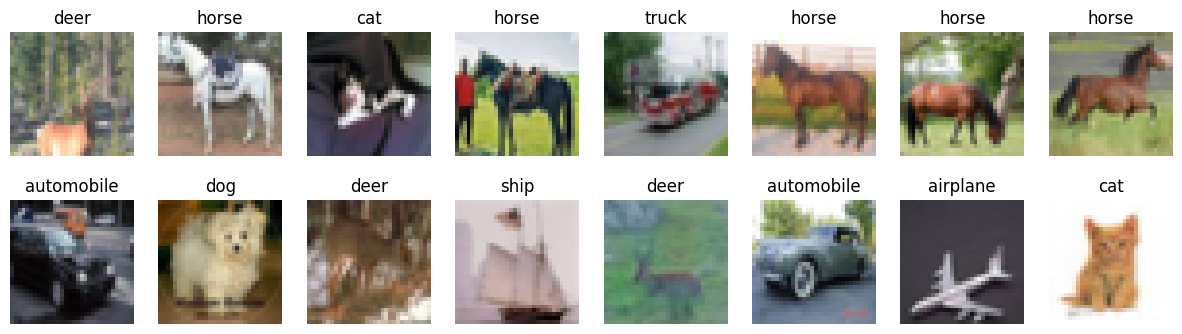

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [123]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from keras.layers import LeakyReLU

In [154]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()

    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network. 
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.

    # add batch normalization after convolutional layers but before activation functions
    # add L2 regularization to convolutinal and dense layers
    # add global avg pooling
    # from tensorflow.keras.layers import GlobalAveragePooling2D

    # Conv2D(filers/kernels, size of each kernel, type of activation function, shape of input)
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # we add max pooling to reduce the number of parameters
    # also making the model not as sensitive to small (irrelevant) features of the image

    # we add another convolutional layer to learn more complex features
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu',))
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    # add pooling again to reduce the number of parameters (more robust)
    model.add(Dropout(0.25))

    # final convolutional layer to learn even more complex features
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu',))
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # we add flatten to convert the 3D -> 1D
    # instead flatten, we can also add a global average pooling layer to reduce the number of parameters and prevent overfitting
    model.add(Flatten())

    # we add dense layers (fully connected, layer dimension=128, activation function = relu)
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(0.5)) # dropout layer with 50% droput rate to prevent overfitting
    model.add(Dense(10, activation="softmax")) 

    return model
    ### END STUDENT CODE ### 

    

Attempt 1: 
32 Kernels (4x4), activation = relu
MaxPooling (2,2)
64 dimnesion dense layer (activation = relu)
10% dropout rate
output softmax
learning rate = 3e-4 (some say it's the best)
batch_size = 512
epochs = 20

Results: accuracy: 0.5113 - loss: 1.3942 - val_accuracy: 0.5288 - val_loss: 1.3601
Note: Constant stable progress on 20 epochs (it would might get 70%+ acc if we do ~ 100 epochs)


Attempt 2:
Changed learning rate to make learning progress quicker
use the learning rate initally given
learning rate = 5e-3

Results: accuracy: 0.7153 - loss: 0.8131 - val_accuracy: 0.6308 - val_loss: 1.0801
Note: seems like overfitting from graphs (validation metrics hit the plateau while training metrics kept improving)


In [161]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training
# add necessary imports for data augmentation and early stopping
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
INIT_LR = 3e-4  # initial learning rate
BATCH_SIZE = 64
EPOCHS = 40


K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR), 
    metrics=['accuracy']  # report accuracy during training
)


# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# fit model
model.fit(
    x_train, y_train, 
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 145ms/step - accuracy: 0.3003 - loss: 1.8964 - val_accuracy: 0.4222 - val_loss: 1.6629
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.4407 - loss: 1.5286 - val_accuracy: 0.4502 - val_loss: 1.5533
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.5015 - loss: 1.3773 - val_accuracy: 0.5558 - val_loss: 1.2311
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.5429 - loss: 1.2615 - val_accuracy: 0.5426 - val_loss: 1.2900
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.5826 - loss: 1.1660 - val_accuracy: 0.6491 - val_loss: 1.0037
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6155 - loss: 1.0840 - val_accuracy: 0.6311 - val_loss: 1.0510
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6364 - loss: 1.0228 - val_accuracy: 0.6836 - val_loss: 0.9029
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 130ms/step - accuracy: 0.6579 - loss: 0

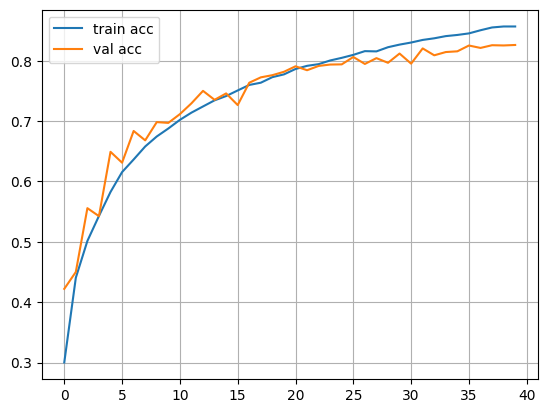

Final training accuracy: 0.8566250205039978
Final validation accuracy: 0.8259999752044678


In [162]:
# accuracy (regular and validation) as a function of epoch
# loss (regular and validation) as a function of epoch

import matplotlib.pyplot as plt

plt.plot(model.history.history['accuracy'], label='train acc')
plt.plot(model.history.history['val_accuracy'], label='val acc')
plt.legend()
plt.grid()
plt.show()

# print final train and validation accuracy
print("Final training accuracy:", model.history.history['accuracy'][-1])
print("Final validation accuracy:", model.history.history['val_accuracy'][-1])

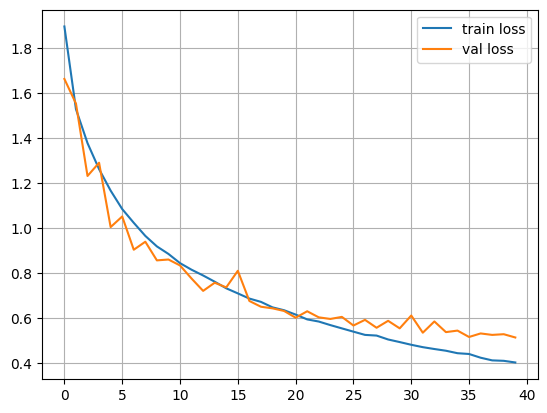

Final training loss: 0.40127989649772644
Final validation loss: 0.512504518032074


In [163]:
# plot loss and val_loss as a function of epoch

plt.plot(model.history.history['loss'], label='train loss')
plt.plot(model.history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.show()

# print final train and validation loss
print("Final training loss:", model.history.history['loss'][-1])
print("Final validation loss:", model.history.history['val_loss'][-1])

In [164]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


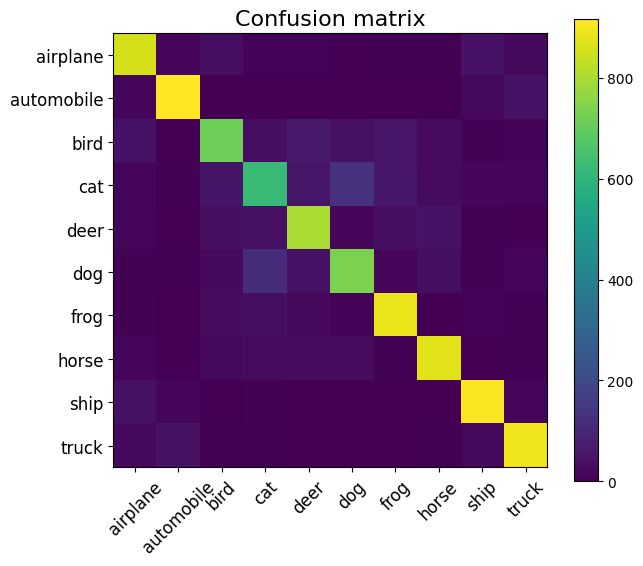

Test accuracy: 0.8213


In [165]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

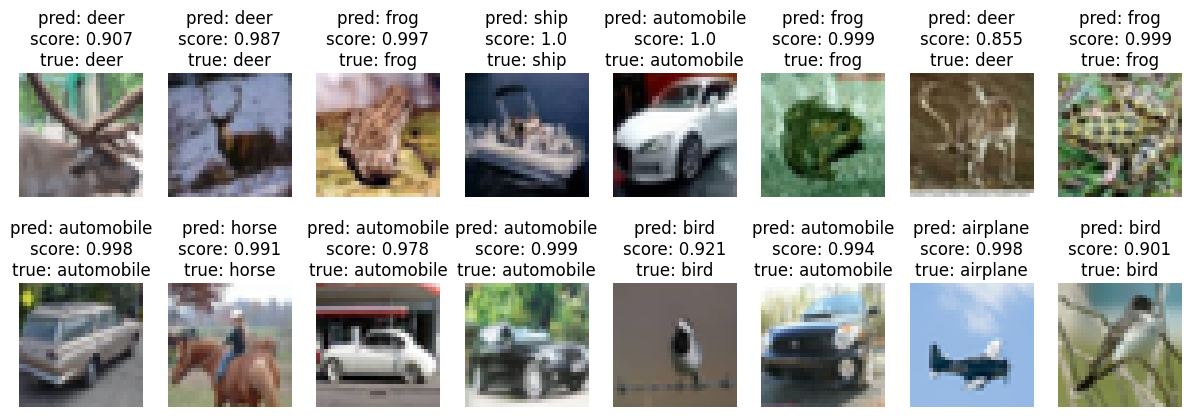

In [166]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons, 
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ - 
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




Attempt 1: 
32 Kernels (4x4), activation = relu
MaxPooling (2,2)
64 dimnesion dense layer (activation = relu)
10% dropout rate
output softmax
learning rate = 3e-4 (some say it's the best)
batch_size = 512
epochs = 20

Results: accuracy: 0.5113 - loss: 1.3942 - val_accuracy: 0.5288 - val_loss: 1.3601
Note: Constant stable progress on 20 epochs (it would might get 70%+ acc if we do ~ 100 epochs)


Attempt 2:
Changed learning rate to make learning progress quicker
use the learning rate initally given
learning rate = 5e-3

Results: accuracy: 0.7153 - loss: 0.8131 - val_accuracy: 0.6308 - val_loss: 1.0801
Note: seems like overfitting from graphs (validation metrics hit the plateau while training metrics kept improving)



Attempt 3: back to same settings as attempt 1; epochs = 40
accuracy: 0.5701 - loss: 1.2261 - val_accuracy: 0.5733 - val_loss: 1.2225
Note: Progress hitting a plateau (additional adjustments necessary - more complexity)

4:
32 Kernels (3x3), activation = relu
MaxPooling (2,2)
64 dimnesion dense layer (activation = relu)
10% dropout rate
output softmax
learning rate = 3e-4 (some say it's the best)
batch_size = 1024
epochs = 20

results: accuracy: 0.4568 - loss: 1.5459 - val_accuracy: 0.4727 - val_loss: 1.4988
Note: reduce batch size to 512 (maybe creates a better result); this progress was okay but seems limited from results as it would reach the limit soon

5:
32 Kernels (3x3), activation = relu
MaxPooling (2,2)
64 dimnesion dense layer (activation = relu)
10% dropout rate
output softmax
learning rate = 3e-4 (some say it's the best)
batch_size = 512
epochs = 20

results: accuracy: 0.5303 - loss: 1.3372 - val_accuracy: 0.5465 - val_loss: 1.3128
note: seems good, let's try larger learning rate maybe it will achieve better results sooner 

6: 
32 Kernels (3x3), activation = relu
MaxPooling (2,2)
64 dimnesion dense layer (activation = relu)
10% dropout rate
output softmax
learning rate = 5e-3 (some say it's the best)
batch_size = 512
epochs = 20

Results:
epoch 19: accuracy: 0.6787 - loss: 0.9079 - val_accuracy: 0.6295 - val_loss: 1.0522
Epoch 20: accuracy: 0.6884 - loss: 0.8880 - val_accuracy: 0.6192 - val_loss: 1.1274
Note: Again, seems like overfitting with this learning rate; stick to 3e-4 (or add more agressive dropout)


7:
INIT_LR = 3e-4  # initial learning rate
BATCH_SIZE = 512
EPOCHS = 20
32 Kernels (3x3), activation = relu
MaxPooling (2,2)
2 additional layers of conv (64 than 128 for more details)
same max pooling after each conv layer
64 dimnesion dense layer (activation = relu)
20% dropout rate (prevent overffiting)
output softmax

reults:
epoch 19: accuracy: 0.4701 - loss: 1.4626 - val_accuracy: 0.5050 - val_loss: 1.3942
epoch 20: 0.4731 - loss: 1.4547 - val_accuracy: 0.5055 - val_loss: 1.3883
Note: training process seems better, more epochs would lead to better results, but let's try further optimization before running 50 epochs with certain model

8: Evrything stays the same except learning rate going to 1e-3 (let's try to make it progress quicker without overfitting)
0.5653 - loss: 1.2189 - val_accuracy: 0.5892 - val_loss: 1.1683

9: batch size = 128
accuracy: 0.6888 - loss: 0.8905 - val_accuracy: 0.6665 - val_loss: 0.9574
note: just started overfitting


10: remove third max pooling by droput of 20%; go back to 3e-4
accuracy: 0.6004 - loss: 1.1414 - val_accuracy: 0.6116 - val_loss: 1.1013
note: smooth progress, room for even better results with more epochs
option: add more dimensions(neurons) to dense layer since we removed third max pooling

11: added more neurons
accuracy: 0.6280 - loss: 1.0595 - val_accuracy: 0.6358 - val_loss: 1.0415
note: seems like it is reaching its limit before overfitting

12:
add batch normalization and regulizer inside each layer
accuracy: 0.8075 - loss: 0.7978 - val_accuracy: 0.7110 - val_loss: 1.0694
note: graphs show some overfitting

13:
Going hard on regulation -> dropout 0.4; L2 = 0.002; batch size = 64
Goal is to keep the complexity and capacity of the model cause it seems it has potential, but prevent overfitting
results: accuracy: 0.7509 - loss: 1.0028 - val_accuracy: 0.7370 - val_loss: 1.0259
note: overfitting reached at epoch 15


14: add more data and early stopping
More data should delay (or prevent) overfitting
- accuracy: 0.6611 - loss: 1.2252 - val_accuracy: 0.7110 - val_loss: 1.0873

15: Increase learning rate -> accuracy: 0.6922 - loss: 1.0746 - val_accuracy: 0.6346 - val_loss: 1.2557
note: overfitting but also, model is to restricted with all the regulation
release it a bit by decreasing dropout give it room to breathe


16: take a step back and set up the following architecture
conv + conv + maxpooling + dropout (25) x3
flatten
dense (512)
dropout 0.5
dense (softmax)
add padding=same -> activation =relu always
Final training accuracy: 0.7800999879837036
Final validation accuracy: 0.7472000122070312
Final training loss: 0.6288214325904846
Final validation loss: 0.7400767803192139
Note: Best validation value actually came in epoch 18 - let's try 40 epochs same setting (add early stopping)

17: Test accuracy: 0.798 (Top acc ~ epoch 25)

18: same settin 25 epochs
Final training accuracy: 0.8030499815940857
Final validation accuracy: 0.7965999841690063
Test accuracy: 0.7912


19: Split activation in final block and put it after bathcnormalization (should give a bit better results)
Note: Potential to improve above 80 in 30-40 epochs
results: accuracy: 0.7980 - loss: 0.5785 - val_accuracy: 0.7849 - val_loss: 0.6292
Test accuracy: 0.7809

